# Modelamiento Supervisado: Regresión y Clasificación

**Caso de Estudio:** Ecommerce Customer Dataset
**Asignatura:** MLY1101 — Machine Learning
**Laboratorio de Modelamiento Supervisado: Regresión y Clasificación**

---

## Descripción

Este notebook corresponde a las **Fases 4 y 5 (Modelado y Evaluación)** de la metodología
CRISP-DM y desarrolla los pasos 2 y 3 del laboratorio. El paso 1 (carga, preparación y encoding
de las variables) está en [`preprocesamiento.ipynb`](preprocesamiento.ipynb).

- **Paso 2 — Clasificación:** predecir si un cliente abandonará la empresa (Exited).
- **Paso 3 — Regresión:** estimar el saldo de un cliente (Balance).

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. Bibliotecas necesarias:

- pandas (>=1.1.0)
- numpy (>=2.0.0)
- matplotlib (>=3.7.1)
- scikit-learn (>=1.3)

# Importación de librerías

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('bmh')

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, f1_score, mean_absolute_error,
                             precision_score, r2_score, recall_score, root_mean_squared_error)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Advertencia espuria de numpy con la librería de cálculo de macOS; no afecta los resultados.
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)

os.makedirs('../images', exist_ok=True)
SEMILLA = 42

# Reconstrucción de la preparación de datos

Se reproducen, sin cambios, la carga, las variables derivadas, la partición y el pipeline de
preparación de [`preprocesamiento.ipynb`](preprocesamiento.ipynb), para que este notebook se
pueda ejecutar por sí solo. La justificación de cada decisión está en ese notebook.

In [2]:
df = pd.read_csv('../data/ecommerce_customer_data.csv')
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

df['distancia_edad_riesgo'] = (df['Age'] - 55).abs()
df['tiene_saldo'] = (df['Balance'] > 0).astype(int)

features_num = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'distancia_edad_riesgo']
features_cat = ['Geography', 'Gender', 'NumOfProducts']
features_bin = ['HasCrCard', 'IsActiveMember', 'tiene_saldo']

features_num_reg = [col for col in features_num if col != 'Balance']
features_bin_reg = [col for col in features_bin if col != 'tiene_saldo']

X = df[features_num + features_cat + features_bin]
y_clf = df['Exited']
y_reg = df['Balance']

X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, stratify=y_clf, random_state=SEMILLA
)
print(f'Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}')

Entrenamiento: (8000, 12) | Prueba: (2000, 12)


In [3]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Elimina variables con alta correlación (multicolinealidad). Las columnas a eliminar se
    aprenden en fit (conjunto de entrenamiento) y se aplican igual en transform.
    """
    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        self.columns_to_drop_ = [
            col for col in upper.columns if any(upper[col] > self.threshold)
        ]
        return self

    def transform(self, X):
        return pd.DataFrame(X).drop(columns=self.columns_to_drop_, errors='ignore')


def construir_pipeline_preparacion(num_cols, cat_cols, bin_cols):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])

    preprocesador = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer,     num_cols),
            ('cat', categorical_transformer, cat_cols),
            ('bin', 'passthrough',           bin_cols)
        ],
        remainder='drop'
    ).set_output(transform='pandas')

    return Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('colinealidad',  CorrelationFilter(threshold=0.9))
    ])


def modelo_completo(num_cols, cat_cols, bin_cols, estimador):
    """Pipeline de preparación + modelo: se entrena todo junto solo con el conjunto de entrenamiento."""
    return Pipeline(steps=[
        ('preparacion', construir_pipeline_preparacion(num_cols, cat_cols, bin_cols)),
        ('modelo',      estimador)
    ])

# Paso 2 — Clasificación: predecir el abandono (Exited)

**Variable objetivo:** Exited (1 = el cliente abandonó, 0 = se mantuvo). **Características:** el
resto de las variables. La partición entrenamiento/prueba (80/20) ya se hizo arriba, estratificada
por Exited para mantener el 20,4% de abandono en ambos conjuntos.

Se entrenan dos modelos:

- **Regresión logística:** modelo lineal, simple e interpretable.
- **Random Forest:** conjunto de árboles de decisión. Puede captar relaciones que no son lineales
  y combinaciones entre variables, como el efecto conjunto de la edad y la actividad que mostró el
  EDA (Sección 4.4).

Como solo el 20,4% de los clientes abandona (EDA, Sección 4.1), ambos modelos se entrenan con
class_weight='balanced', que le da más peso a los clientes que abandonan. Sin esto, los
modelos tienden a predecir casi siempre "se mantiene".

**Métricas:**

- **Accuracy:** % de clientes clasificados correctamente. Por el desbalance no basta por sí sola:
  predecir siempre "se mantiene" ya da 79,6%.
- **Recall:** de los clientes que realmente abandonan, qué % detecta el modelo.
- **Precisión:** de los clientes que el modelo marca como "abandonará", qué % realmente abandona.
- **F1:** resume en un solo número el equilibrio entre precisión y recall.

In [4]:
modelos_clasificacion = {
    'Regresión logística': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                  class_weight='balanced', random_state=SEMILLA),
}

predicciones_clf = {}
filas = []
for nombre, estimador in modelos_clasificacion.items():
    modelo = modelo_completo(features_num, features_cat, features_bin, estimador)
    modelo.fit(X_train, y_clf_train)
    pred = modelo.predict(X_test)
    predicciones_clf[nombre] = pred
    modelos_clasificacion[nombre] = modelo
    filas.append({
        'modelo':    nombre,
        'accuracy':  accuracy_score(y_clf_test, pred),
        'precision': precision_score(y_clf_test, pred),
        'recall':    recall_score(y_clf_test, pred),
        'f1':        f1_score(y_clf_test, pred),
    })

pd.DataFrame(filas).set_index('modelo').round(3)

,accuracy,precision,recall,f1
modelo,,,,
Regresión logística,0.768,0.458,0.752,0.569
Random Forest,0.835,0.587,0.639,0.612


- La **regresión logística** detecta más abandonos (recall 0,752), pero con más falsas alarmas
  (precisión 0,458): menos de la mitad de los clientes que marca como "abandonará" realmente
  abandona.
- El **Random Forest** está más equilibrado: detecta menos abandonos (recall 0,639) pero acierta
  más cuando alerta (precisión 0,587), y tiene el mejor F1 (0,612) y la mejor accuracy (0,835).
- Ambos superan a la referencia de predecir siempre "se mantiene", que tiene accuracy 0,796 pero
  no detecta ningún abandono (recall 0).

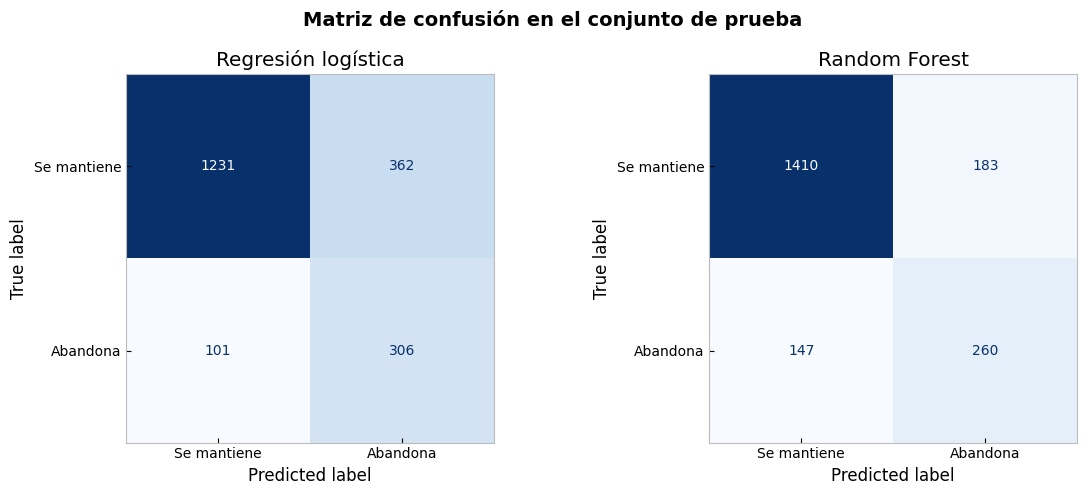

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, pred) in zip(axes, predicciones_clf.items()):
    ConfusionMatrixDisplay.from_predictions(y_clf_test, pred, display_labels=['Se mantiene', 'Abandona'],
                                            cmap='Blues', colorbar=False, ax=ax)
    ax.set_title(nombre)
    ax.grid(False)
plt.suptitle('Matriz de confusión en el conjunto de prueba', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/clasificacion_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

La matriz de confusión muestra los aciertos y errores en los 2.000 clientes de prueba (407
abandonaron):

| | Regresión logística | Random Forest |
|---|---:|---:|
| Abandonos detectados | 306 de 407 | 260 de 407 |
| Abandonos no detectados | 101 | 147 |
| Falsas alarmas (se marca "abandona" pero se mantiene) | 362 | 183 |

**¿Cuál conviene?** Depende de lo que le cueste más al negocio. Si perder un cliente es mucho
más caro que contactar a uno que no se iba a ir, conviene la regresión logística, que detecta 46
abandonos más. Si la campaña de retención es cara y se quiere contactar a menos clientes, conviene
el Random Forest, que genera la mitad de falsas alarmas.

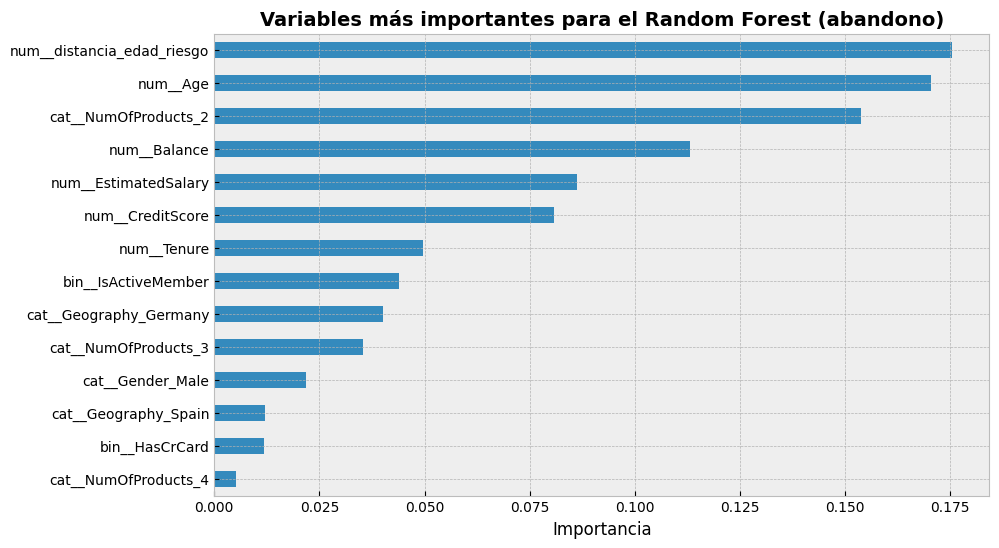

In [6]:
random_forest = modelos_clasificacion['Random Forest']
columnas_modelo = random_forest.named_steps['preparacion'].transform(X_train.head()).columns

importancia = pd.Series(random_forest.named_steps['modelo'].feature_importances_,
                        index=columnas_modelo).sort_values()

importancia.plot(kind='barh', figsize=(10, 6))
plt.title('Variables más importantes para el Random Forest (abandono)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.savefig('../images/importancia_variables_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

La importancia muestra qué tanto usa el Random Forest cada variable para decidir:

- **distancia_edad_riesgo** y **Age** son las más usadas: coincide con el EDA, donde la edad fue
  el factor más relacionado con el abandono (Sección 4.3).
- **Tener 2 productos** (cat__NumOfProducts_2) es la tercera: coincide con el efecto de la
  cantidad de productos del EDA (Sección 4.2).
- Luego aparecen **Balance**, **IsActiveMember** y **Geography_Germany**, también señaladas en el
  EDA.

Hay que leer este gráfico con cuidado: esta forma de medir la importancia favorece a las
variables numéricas con muchos valores distintos. Por eso EstimatedSalary y CreditScore aparecen
en un nivel medio, aunque el EDA mostró que no cambian el abandono (Sección 4.7).

# Paso 3 — Regresión: estimar el saldo (Balance)

**Variable objetivo:** Balance. **Características:** el resto de las variables, excluyendo
Balance y lo que se calcula a partir de él (tiene_saldo). También se excluye Exited: el
abandono ocurre después del saldo observado, así que no es un dato disponible al momento de
estimar el saldo de un cliente actual. Se usa la misma partición entrenamiento/prueba.

Se entrenan dos modelos:

- **Regresión lineal:** modelo lineal simple, punto de partida.
- **Random Forest:** puede captar relaciones que no son lineales, como la de la cantidad de
  productos con el saldo (EDA, Sección 5.3).

**Métricas:**

- **MAE** (error absoluto medio): cuánto se equivoca el modelo en promedio, en la misma unidad
  que Balance.
- **RMSE:** como el MAE, pero castiga más los errores grandes.
- **R²:** qué parte de la variación del saldo explica el modelo (0 = nada, 1 = todo).

Como referencia se incluye una **línea base** que predice siempre el saldo promedio de
entrenamiento: un modelo solo es útil si se equivoca menos que ella.

In [7]:
modelos_regresion = {
    'Regresión lineal': LinearRegression(),
    'Random Forest':    RandomForestRegressor(n_estimators=300, min_samples_leaf=10, random_state=SEMILLA),
}

pred_base = np.full(len(y_reg_test), y_reg_train.mean())
filas = [{
    'modelo': 'Línea base (promedio)',
    'MAE':    mean_absolute_error(y_reg_test, pred_base),
    'RMSE':   root_mean_squared_error(y_reg_test, pred_base),
    'R2':     r2_score(y_reg_test, pred_base),
}]
predicciones_reg = {}
for nombre, estimador in modelos_regresion.items():
    modelo = modelo_completo(features_num_reg, features_cat, features_bin_reg, estimador)
    modelo.fit(X_train, y_reg_train)
    pred = modelo.predict(X_test)
    predicciones_reg[nombre] = pred
    modelos_regresion[nombre] = modelo
    filas.append({
        'modelo': nombre,
        'MAE':    mean_absolute_error(y_reg_test, pred),
        'RMSE':   root_mean_squared_error(y_reg_test, pred),
        'R2':     r2_score(y_reg_test, pred),
    })

pd.DataFrame(filas).set_index('modelo').round(3)

,MAE,RMSE,R2
modelo,,,
Línea base (promedio),57090.578,62777.752,-0.000
Regresión lineal,45079.797,53031.856,0.286
Random Forest,41576.038,52197.665,0.309


- Los dos modelos se equivocan menos que la línea base: el MAE baja de ~57.100 a ~45.100
  (regresión lineal) y ~41.600 (Random Forest).
- El **Random Forest** es el mejor, pero solo explica el 31% de la variación del saldo
  (R² = 0,309).

Es un resultado modesto, pero coherente con el EDA: fuera del país y la cantidad de productos,
el saldo no se relaciona con ningún otro atributo del cliente (Sección 5).

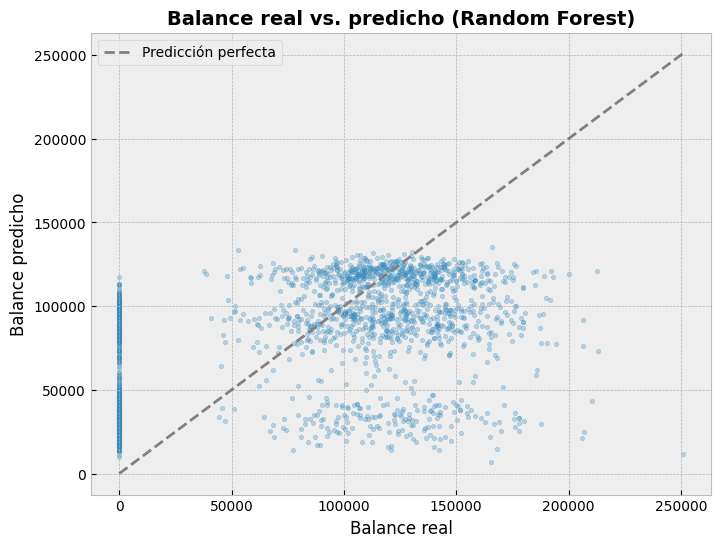

In [8]:
pred_rf = predicciones_reg['Random Forest']

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, pred_rf, alpha=0.3, s=10)
plt.plot([0, y_reg_test.max()], [0, y_reg_test.max()], color='gray', linestyle='--', label='Predicción perfecta')
plt.title('Balance real vs. predicho (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Balance real')
plt.ylabel('Balance predicho')
plt.legend()
plt.savefig('../images/regresion_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

El gráfico muestra el problema principal: la columna de puntos en Balance real = 0 son clientes
sin saldo a los que el modelo les estima entre ~10.000 y ~115.000. El 36% de los clientes tiene
saldo 0 (EDA, Sección 5.2), y con las variables disponibles el modelo no logra distinguirlos del
resto. Las predicciones se agrupan en franjas horizontales: el modelo estima el saldo típico de
cada grupo de clientes (según país y cantidad de productos), no el de cada cliente.

## Regresión con y sin los países

El EDA mostró que ser de Alemania es la variable más relacionada con el saldo (correlación 0,40,
Sección 3.3), pero que esa relación probablemente se debe a cómo se armó la muestra: ningún
cliente alemán tiene saldo 0 (Sección 2.7). Si el modelo se apoya en ese patrón, sus métricas se
verán mejores de lo que serían con clientes reales.

Para medirlo, se entrenan los mismos dos modelos **sin la variable Geography** y se comparan con
los resultados de arriba, que sí la incluyen.

In [9]:
sin_paises = [col for col in features_cat if col != 'Geography']

filas = []
predicciones_sin_paises = {}
for nombre, estimador in [
    ('Regresión lineal', LinearRegression()),
    ('Random Forest',    RandomForestRegressor(n_estimators=300, min_samples_leaf=10, random_state=SEMILLA)),
]:
    for version, categoricas in [('con países', features_cat), ('sin países', sin_paises)]:
        modelo = modelo_completo(features_num_reg, categoricas, features_bin_reg, estimador)
        modelo.fit(X_train, y_reg_train)
        pred = modelo.predict(X_test)
        if version == 'sin países':
            predicciones_sin_paises[nombre] = pred
        filas.append({
            'modelo':  nombre,
            'version': version,
            'MAE':     mean_absolute_error(y_reg_test, pred),
            'RMSE':    root_mean_squared_error(y_reg_test, pred),
            'R2':      r2_score(y_reg_test, pred),
        })

pd.DataFrame(filas).set_index(['modelo', 'version']).round(3)

MAE       RMSE     R2
modelo           version                                
Regresión lineal con países  45079.797  53031.856  0.286
                 sin países  50645.353  58520.158  0.131
Random Forest    con países  41576.038  52197.665  0.309
                 sin países  50761.984  59320.671  0.107

| Modelo | R² con países | R² sin países | MAE con países | MAE sin países |
|---|---:|---:|---:|---:|
| Regresión lineal | 0,286 | 0,131 | 45.080 | 50.645 |
| Random Forest | 0,309 | 0,107 | 41.576 | 50.762 |

**Sin los países, los dos modelos pierden más de la mitad de su R²**, y el error medio sube
~5.500 en la regresión lineal y ~9.200 en el Random Forest. Es decir, buena parte de lo que
parecían explicar los modelos venía de un solo patrón: distinguir a los clientes alemanes (todos
con saldo) del resto.

Sin países, los modelos siguen siendo mejores que la línea base (MAE ~50.700 contra ~57.100),
pero solo un 11% mejores. Además, la regresión lineal queda levemente por encima del Random
Forest: sin el país, las relaciones que quedan (sobre todo la cantidad de productos) son simples
y un modelo lineal las capta igual de bien.

Para entender de dónde sale el R² del modelo con países, se calcula por separado para los
clientes de Alemania y los de Francia/España del conjunto de prueba:

In [10]:
es_alemania = X_test['Geography'] == 'Germany'
r2_por_grupo = pd.DataFrame({
    'con países': [r2_score(y_reg_test[es_alemania], pred_rf[es_alemania]),
                   r2_score(y_reg_test[~es_alemania], pred_rf[~es_alemania])],
    'sin países': [r2_score(y_reg_test[es_alemania], predicciones_sin_paises['Random Forest'][es_alemania]),
                   r2_score(y_reg_test[~es_alemania], predicciones_sin_paises['Random Forest'][~es_alemania])],
}, index=['Alemania', 'Francia/España'])
print('R² del Random Forest por grupo de clientes:')
r2_por_grupo.round(3)

R² del Random Forest por grupo de clientes:


,con países,sin países
Alemania,-0.039,-3.427
Francia/España,0.185,0.126


- **Con países**, el modelo no explica nada dentro de Alemania (R² ≈ -0,04): no sabe qué cliente
  alemán tiene más o menos saldo, solo que en promedio tienen más. En Francia y España explica
  el 18,5%.
- **Sin países**, el R² en Alemania cae a -3,43: el modelo ya no sabe que un cliente es alemán y le
  estima saldos bajos como a muchos franceses y españoles, cuando en realidad todos tienen saldo.
  En Francia y España baja de 0,185 a 0,126.

**¿Cuál usar?** Con los datos de este dataset, el modelo con países tiene mejores métricas. Pero
esas métricas se apoyan en un patrón que probablemente se debe a cómo se armó la muestra, así
que no reflejan lo que el modelo lograría con clientes reales. **La estimación honesta de su
desempeño es la de los resultados sin países o la de Francia y España: el modelo explica entre
un 11% y un 19% del saldo.**

## ¿Qué aprende realmente el modelo de regresión?

El EDA mostró que Balance está **inflado en cero**: el 36% de los clientes tiene saldo 0 y el
resto se concentra en torno a ~120.000 (Sección 5.2). Para entender qué capta el modelo, se
evalúa el Random Forest (con países) por separado en los clientes con saldo 0 y en los clientes
con saldo, y se mide si sus predicciones siguen al saldo real dentro de cada grupo.

In [11]:
grupo_saldo = np.where(y_reg_test > 0, 'Con saldo', 'Saldo 0')
evaluacion = pd.DataFrame({'real': y_reg_test, 'predicho': pred_rf, 'grupo': grupo_saldo})
evaluacion['error_absoluto'] = (evaluacion['real'] - evaluacion['predicho']).abs()

por_grupo = evaluacion.groupby('grupo').agg(
    clientes=('real', 'size'),
    saldo_real_promedio=('real', 'mean'),
    saldo_predicho_promedio=('predicho', 'mean'),
    MAE=('error_absoluto', 'mean'),
)
print(por_grupo.round(0), '\n')

con_saldo = y_reg_test > 0
print(f"Correlación entre predicción y saldo real (todos):             {np.corrcoef(y_reg_test, pred_rf)[0, 1]:.3f}")
print(f"Correlación entre predicción y saldo real (solo con saldo):    {np.corrcoef(y_reg_test[con_saldo], pred_rf[con_saldo])[0, 1]:.3f}")

           clientes  saldo_real_promedio  saldo_predicho_promedio      MAE
grupo                                                                     
Con saldo      1274             120729.0                  93184.0  38249.0
Saldo 0         726                  0.0                  47414.0  47414.0 

Correlación entre predicción y saldo real (todos):             0.556
Correlación entre predicción y saldo real (solo con saldo):    -0.011


- El modelo le estima en promedio **~47.000 a los clientes con saldo 0** y **~93.000 a los que
  tienen ~121.000**: separa a los dos grupos solo a medias, y se equivoca en ambos (MAE de ~47.000
  y ~38.000).
- En total, sus predicciones se relacionan con el saldo real (correlación 0,56). Pero **entre los
  clientes que tienen saldo, la correlación es prácticamente 0 (-0,01)**: el modelo no capta si un
  cliente tiene 60.000 o 180.000.

Es decir, **todo lo que el modelo aprende es a distinguir, a medias, quién tiene saldo y quién
no**. Cuánto saldo tiene un cliente no se puede predecir con las variables disponibles. Esto
cambia cómo leer el R²: no mide qué tan bien se estiman los montos, sino qué tan bien se separa a
los clientes con saldo 0 del resto.

**Conclusión para el negocio:** el objetivo de la guía, proyectar el volumen de fondos que un
cliente mantendrá en su cuenta, no se puede cumplir con estos datos. Lo que sí entrega el modelo
es una idea de qué clientes probablemente tienen fondos y cuáles no.

# Resumen

**Paso 2 — Clasificación (Exited):**

- Se entrenaron una regresión logística y un Random Forest, ambos con class_weight='balanced'
  por el desbalance de clases.
- El **Random Forest** tiene el mejor equilibrio (F1 = 0,612, accuracy = 0,835): detecta 260 de 407
  abandonos con 183 falsas alarmas. La regresión logística detecta más abandonos (306) pero con el
  doble de falsas alarmas (362).
- Las variables que más usa el modelo (edad, cantidad de productos, saldo, actividad y país)
  coinciden con los hallazgos del EDA.

**Paso 3 — Regresión (Balance):**

- Se entrenaron una regresión lineal y un Random Forest. El **Random Forest** es el mejor
  (MAE = 41.576, R² = 0,309), un 27% menos de error absoluto que predecir siempre el promedio.
- **Con y sin países:** sin la variable Geography, el R² cae de 0,309 a 0,107 (Random Forest) y
  de 0,286 a 0,131 (regresión lineal). Más de la mitad del desempeño venía de distinguir a los
  clientes alemanes, un patrón que probablemente se debe a cómo se armó la muestra. La estimación
  honesta es que el modelo explica entre un 11% y un 19% del saldo.
- **Lo que realmente aprende el modelo** es a distinguir, a medias, a los clientes con saldo 0 del
  resto. Entre los clientes con saldo, sus predicciones no se relacionan con el monto real
  (correlación -0,01): el volumen de fondos de un cliente no se puede proyectar con estas
  variables.
- Sirve para estimar el saldo típico de un grupo de clientes, no el saldo de un cliente en
  particular.

**Nota ética:** el modelo de clasificación usa el género y el país. Antes de usarlo para decidir a
quién ofrecer una campaña de retención, habría que revisar si comete errores parecidos con
hombres y mujeres y entre países, para no tratar distinto a los clientes por esas características.